# Gamma Distribution

The **Gamma distribution** is a flexible two-parameter family for positive, right-skewed data. It generalises the Exponential (shape=1) and Chi-square (shape=ν/2, scale=2), and models waiting times for multiple events, insurance claims, and rainfall amounts.

| Property | Value |
|---|---|
| **Parameters** | γ (shape, γ > 0), β (scale, β > 0), μ (location) |
| **Support** | (μ, +∞) |
| **PDF** | f(x) = ((x−μ)/β)^(γ−1) · exp(−(x−μ)/β) / (β · Γ(γ)) |
| **Mean** | μ + γβ |
| **Variance** | γβ² |
| **Mode** | μ + (γ−1)β for γ ≥ 1 |
| **Skewness** | 2/√γ (decreases as γ↑) |
| **Special cases** | γ=1 → Exponential(β); γ=ν/2, β=2 → χ²(ν) |
| **Estimation** | MOM: γ̂=x̄²/s², β̂=s²/x̄; MLE: numerical |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

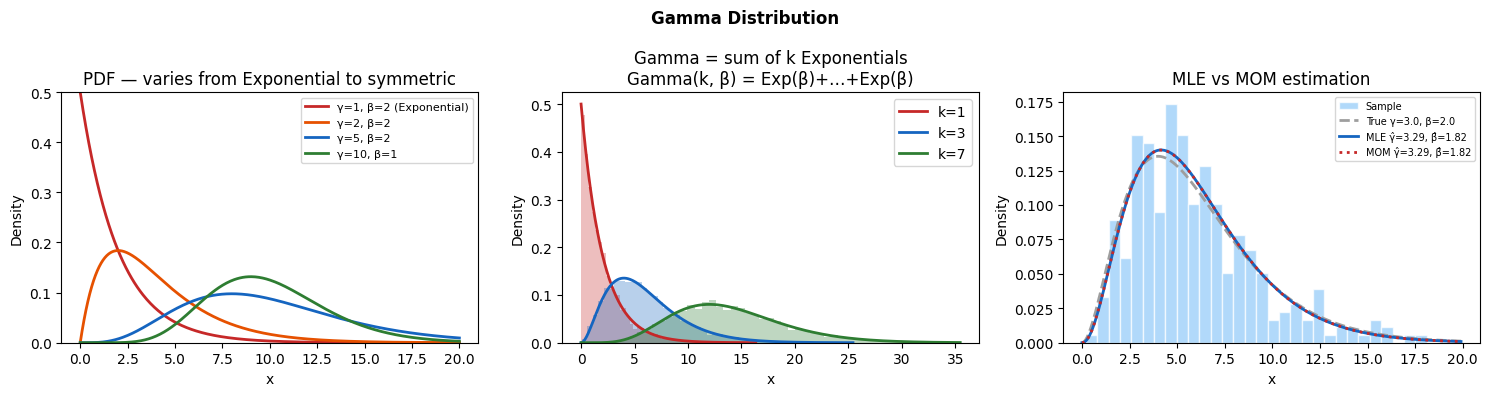

In [2]:
x = np.linspace(0.001, 20, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Gamma Distribution', fontsize=12, fontweight='bold')

# PDF — scipy: a=shape(γ), scale=β
for gamma, beta, color, label in [(1,   2, '#C62828', 'γ=1, β=2 (Exponential)'),
                                    (2,   2, '#E65100', 'γ=2, β=2'),
                                    (5,   2, '#1565C0', 'γ=5, β=2'),
                                    (10,  1, '#2E7D32', 'γ=10, β=1')]:
    axes[0].plot(x, stats.gamma(a=gamma, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — varies from Exponential to symmetric')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=8)

# Relationship: Gamma(k, β) = sum of k Exponential(β)
np.random.seed(42)
beta_val = 2.0
n_sim = 5000
for k, color, label in [(1, '#C62828', 'k=1'), (3, '#1565C0', 'k=3'), (7, '#2E7D32', 'k=7')]:
    # Sum of k Exponentials
    summed = np.sum(stats.expon(scale=beta_val).rvs((n_sim, k)), axis=1)
    x_range = np.linspace(0, summed.max(), 300)
    axes[1].hist(summed, bins=50, density=True, alpha=0.3, color=color)
    axes[1].plot(x_range, stats.gamma(a=k, scale=beta_val).pdf(x_range), color=color, linewidth=2, label=label)
axes[1].set_title('Gamma = sum of k Exponentials\nGamma(k, β) = Exp(β)+…+Exp(β)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# MOM and MLE fit
true_gamma, true_beta = 3.0, 2.0
data = stats.gamma(a=true_gamma, scale=true_beta).rvs(300, random_state=42)

# MOM
xbar, s2 = data.mean(), data.var()
beta_mom = s2 / xbar
gamma_mom = xbar / beta_mom

# MLE
gamma_mle, loc_mle, beta_mle = stats.gamma.fit(data, floc=0)

x_plot = np.linspace(0, data.max()*1.1, 300)
axes[2].hist(data, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7, label='Sample')
axes[2].plot(x_plot, stats.gamma(a=true_gamma, scale=true_beta).pdf(x_plot),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True γ={true_gamma}, β={true_beta}')
axes[2].plot(x_plot, stats.gamma(a=gamma_mle, scale=beta_mle).pdf(x_plot),
             color='#1565C0', linewidth=2, label=f'MLE γ̂={gamma_mle:.2f}, β̂={beta_mle:.2f}')
axes[2].plot(x_plot, stats.gamma(a=gamma_mom, scale=beta_mom).pdf(x_plot),
             color='#C62828', linewidth=2, linestyle=':', label=f'MOM γ̂={gamma_mom:.2f}, β̂={beta_mom:.2f}')
axes[2].set_title('MLE vs MOM estimation')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Special cases** | γ=1 → Exponential; γ=ν/2, β=2 → χ²(ν) |
| **Additive** | Sum of k independent Gamma(γ,β) ~ Gamma(kγ,β) |
| **Sum of Exponentials** | k independent Exp(β) variables sum to Gamma(k, β) |
| **Skewness** | 2/√γ — decreases as γ increases; approaches Normal at large γ |
| **MOM** | γ̂ = x̄²/s², β̂ = s²/x̄ — simple closed form |
| **Use cases** | Waiting time for k events, rainfall totals, insurance claim sizes, Bayesian conjugate prior for Poisson rate |